In [4]:
#@title ✅ Setup: Packages, Imports & Utilities
!pip -q install "pandas>=2.0" "sqlalchemy>=2.0" "psycopg2-binary>=2.9" numpy matplotlib

import math
from dataclasses import dataclass
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

You should consider upgrading via the '/Users/jensmuders/Projects/zepp_to_influxdb/venv/bin/python3 -m pip install --upgrade pip' command.


In [87]:
from influxdb import InfluxDBClient

client = InfluxDBClient(host='localhost', 
                            port=8086, 
                            username='admin', 
                            password='gPnVk54OCFXBI7oKsqZv8K6DqSL2a5gweA2fjjFOgbCMOgSyJVrNOurfcZ4Pk8AYvuvHeM7_Fz3Y7KeRN_woXw==', 
                            database='zepp_gui')

# Query data
#query = "SELECT time AS ts, heart_rate_secs AS hr FROM zepp WHERE time > '2025-09-07T05:30:00Z' and time <= '2025-09-07T05:50:00Z'"
#query = "SELECT time AS ts, heart_rate_secs AS hr FROM zepp WHERE time > '2025-09-04T04:00:00Z' and time <= '2025-09-04T04:30:00Z'"
#query = "SELECT time AS ts, heart_rate_secs AS hr FROM zepp WHERE time > '2025-09-02T03:00:00Z' and time <= '2025-09-02T04:00:00Z'"
query = "SELECT time AS ts, heart_rate_secs AS hr FROM zepp WHERE time > '2025-09-08T11:00:00Z' and time <= '2025-09-08T12:00:00Z'"

result = client.query(query)

# Convert to Pandas DataFrame
data_points = list(result.get_points())
df = pd.DataFrame(data_points)
df['ts'] = pd.to_datetime(df['ts'])
print('Size of dataframe:', df.shape)
df.head()

Size of dataframe: (3578, 2)


,ts,hr
0,2025-09-08 11:00:01+00:00,104
1,2025-09-08 11:00:02+00:00,103
2,2025-09-08 11:00:03+00:00,102
3,2025-09-08 11:00:04+00:00,102
4,2025-09-08 11:00:05+00:00,101


In [88]:
@dataclass
class ThresholdConfiguration:
    rapid_increase_threshold: float = 20.0  # bpm per sample
    elevation_multiplier: float = 1.3       # 30% above baseline
    sustained_elevation_threshold: float = 1.2  # 20% above baseline
    sustained_elevation_duration: int = 60      # seconds
    pattern_window_size: int = 10
    pattern_bpm_delta: float = 40.0

thresholds = ThresholdConfiguration()

<Figure size 1200x200 with 0 Axes>

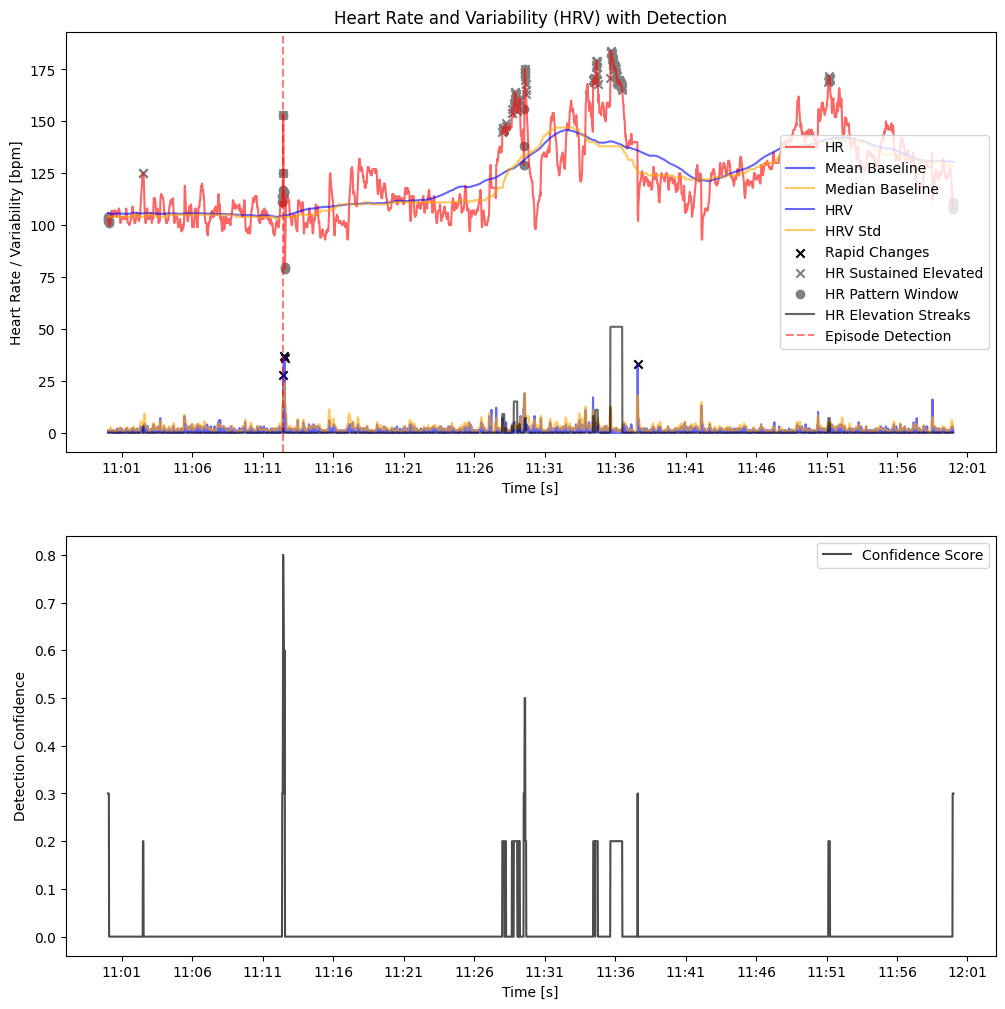

In [92]:
# filter out noise from the heart rate data
#df['hr'] = df['hr'].rolling(window=2, center=True).mean()

window = 600
min_periods = 5

# compute based on heart rate
df['mean_baseline'] = df['hr'].rolling(window=window, min_periods=min_periods, center=True).mean()
df['median_baseline'] = df['hr'].rolling(window=window, min_periods=min_periods, center=True).median()

# compute the heart rate variability (HRV)
window = 10
min_periods = 5

df["hrv"] = df["hr"].diff().abs()
df["hrv_std"] = df["hr"].rolling(window=window, min_periods=min_periods, center=True).std()

# Rolling-Mean & Rolling-Std
df["rolling_mean"] = df["hrv"].rolling(window=window, min_periods=min_periods, center=True).mean()
df["rolling_std"] = df["hrv"].rolling(window=window, min_periods=min_periods, center=True).std()

# mark rapid changes
df["hrv_rapid_change"] = df["hrv"] > thresholds.rapid_increase_threshold

# mark elevated heart rate
df["hr_elevated"] = df["hr"] > (df["median_baseline"] * thresholds.elevation_multiplier)

# Calculate elevated heart rate streaks with start and end times
df["hr_sustained_elevated"] = df["hr"] > (df["median_baseline"] * thresholds.sustained_elevation_threshold)

df['elevated_group'] = (df["hr_sustained_elevated"] != df["hr_sustained_elevated"].shift()).cumsum()
elevated_streaks = df[df["hr_sustained_elevated"]].groupby('elevated_group').agg(
    start_idx=('ts', 'first'),
    end_idx=('ts', 'last'),
    streak_len=('ts', 'count')
).reset_index()

# Mark streak intervals in the dataframe for plotting
df['hr_elevation_streaks'] = 0
for _, row in elevated_streaks.iterrows():
    mask = (df['ts'] >= row['start_idx']) & (df['ts'] <= row['end_idx'])
    df.loc[mask, 'hr_elevation_streaks'] = row['streak_len']

df['hr_pattern_window'] = df['hr'].rolling(window=thresholds.pattern_window_size, min_periods=thresholds.pattern_window_size, center=True).apply(lambda x: (x.max() - x.min()) > thresholds.pattern_bpm_delta, raw=True).astype(bool)

# compute confidence score in pandas
df["confidence_score"] = (
    df["hrv_rapid_change"].astype(float) * 0.3 +
    df["hr_sustained_elevated"].astype(float) * 0.2 + 
    (df['hr_elevation_streaks'] > thresholds.sustained_elevation_duration).astype(float) * 0.2 + 
    df["hr_pattern_window"].astype(float) * 0.3
)

df['episode_detection'] = df['confidence_score'] >= 0.7

# put outliers in the same plot as HRV
plt.figure(figsize=(12, 2))
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

ax1.plot(df['ts'], df["hr"], label="HR", alpha=0.6, color='red')
ax1.plot(df['ts'], df["mean_baseline"], label="Mean Baseline", alpha=0.6, color='blue')
ax1.plot(df['ts'], df["median_baseline"], label="Median Baseline", alpha=0.6, color='orange')

ax1.plot(df['ts'], df["hrv"], label="HRV", alpha=0.6, color='blue')
ax1.plot(df['ts'], df["hrv_std"], label="HRV Std", alpha=0.6, color='orange')

ax1.scatter(df[df["hrv_rapid_change"]]['ts'], df[df["hrv_rapid_change"]]["hrv"], color='black', label="Rapid Changes", marker='x')
ax1.scatter(df[df["hr_sustained_elevated"]]['ts'], df[df["hr_sustained_elevated"]]["hr"], color='grey', label="HR Sustained Elevated", marker='x')
ax1.scatter(df[df["hr_pattern_window"]]['ts'], df[df["hr_pattern_window"]]["hr"], color='grey', label="HR Pattern Window", marker='o')

ax1.plot(df['ts'], df["hr_elevation_streaks"], label="HR Elevation Streaks", alpha=0.6, color='black')

# draw a vertical line for each episode detection
for idx in df[df['episode_detection']].index:
    ax1.axvline(x=df.at[idx, 'ts'], color='red', linestyle='--', alpha=0.5, label='Episode Detection')

ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Heart Rate / Variability [bpm]")
ax1.set_title("Heart Rate and Variability (HRV) with Detection")
ax1.legend(loc="best")

ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

ax2.plot(df['ts'], df["confidence_score"], label="Confidence Score", color='black', alpha=0.7)

ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.xlabel("Time [s]")
plt.ylabel("Detection Confidence")
plt.legend(loc="best")
plt.show()